# PETR4 — Extração e Pré-processamento para LSTM

Pipeline completo:
1. Extração de dados via `yfinance` (últimos 12 meses)
2. Análise exploratória
3. Tratamento de valores nulos
4. Detecção e tratamento de outliers
5. Preparação dos dados para treinamento do modelo LSTM

## 1. Importações

In [57]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

## 2. Extração de Dados — PETR4.SA via yfinance

In [58]:
TICKER = "PETR4.SA"
END_DATE = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - timedelta(days=730)).strftime("%Y-%m-%d") #2 anos

print(f"Período {START_DATE} à {END_DATE}")

raw_df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
raw_df.columns = raw_df.columns.get_level_values(0)   # remove MultiIndex se presente
raw_df.index.name = "Date"
raw_df.head()

Período 2024-05-20 à 2026-05-20


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-05-20,28.5107,28.8908,28.4176,28.4952,40400400
2024-05-21,28.4564,28.7744,28.3710,28.5417,27967400
2024-05-22,28.8443,29.0615,28.2469,28.3167,36528800
2024-05-23,28.5572,29.2554,28.3710,29.0460,47987800
2024-05-24,28.4021,28.8520,28.3710,28.7589,23684700


## 3. Análise Exploratória Inicial (EDA)

In [59]:
print("Tipos de dados")
print(raw_df.dtypes)
print("\n..Estatísticas descritivas e quartis")
raw_df.describe()

Tipos de dados
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

..Estatísticas descritivas e quartis


Price,Close,High,Low,Open,Volume
count,499.0000,499.0000,499.0000,499.0000,499.0000
mean,32.3264,32.6583,32.0008,32.3297,37494190.5812
std,5.2583,5.3326,5.1222,5.2088,18180977.2273
min,26.9238,27.5047,26.9238,27.3237,9356900.0000
25%,29.4228,29.7271,29.1791,29.4455,25031300.0000
50%,30.4188,30.7353,30.1451,30.5217,32648200.0000
75%,32.5812,32.8248,32.2579,32.5332,45889950.0000
max,49.3400,50.0066,48.9200,49.3949,129693500.0000


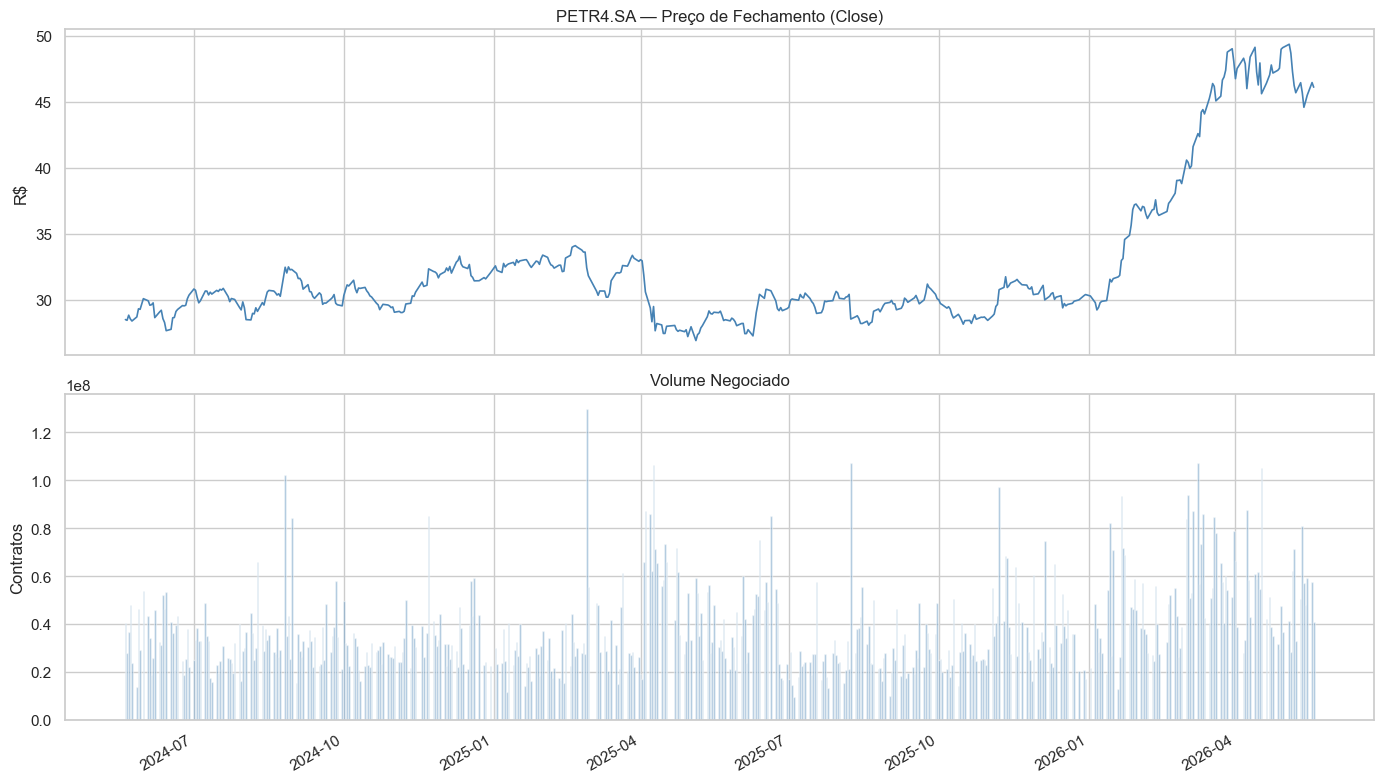

In [60]:
# Série temporal do preço de fechamento e volume negociado
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(raw_df.index, raw_df["Close"], color="steelblue", linewidth=1.2)
axes[0].set_title(f"{TICKER} — Preço de Fechamento (Close)")
axes[0].set_ylabel("R$")

axes[1].bar(raw_df.index, raw_df["Volume"], color="steelblue", alpha=0.5, width=1)
axes[1].set_title("Volume Negociado")
axes[1].set_ylabel("Contratos")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Tratamento de Valores Nulos

In [61]:
df = raw_df.copy()

print("=== Valores nulos por coluna (antes do tratamento) ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal de nulos: {null_counts.sum()}")

=== Valores nulos por coluna (antes do tratamento) ===
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Total de nulos: 0


In [62]:
# Reindexação para garantir continuidade diária (dias úteis) e expor lacunas ocultas
# reindex_end = ontem: yfinance (end exclusivo) já entrega até ontem; incluir hoje criaria linha NaN fantasma
reindex_end = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")
business_days = pd.bdate_range(start=START_DATE, end=reindex_end)
df = df.reindex(business_days)
df.index.name = "Date"

print(f"Dias úteis esperados : {len(business_days)}")
print(f"Linhas após reindex  : {len(df)}")
print(f"\nValores nulos após reindex:")
print(df.isnull().sum())

Dias úteis esperados : 522
Linhas após reindex  : 522

Valores nulos após reindex:
Price
Close     23
High      23
Low       23
Open      23
Volume    23
dtype: int64


In [63]:
# Estratégia de imputação:
#   - Preços (Open/High/Low/Close): interpolação linear (mantém tendência entre pregões)
#   - Volume: forward fill (replica o último volume conhecido)

price_cols  = ["Open", "High", "Low", "Close"]
volume_col  = ["Volume"]

df[price_cols] = df[price_cols].interpolate(method="time")
df[volume_col] = df[volume_col].ffill().bfill()

print("=== Valores nulos após tratamento ===")
print(df.isnull().sum())
print("\nNenhum nulo restante." if df.isnull().sum().sum() == 0 else "ATENÇÃO: ainda há nulos.")
df.head(10)

=== Valores nulos após tratamento ===
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Nenhum nulo restante.


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-05-20,28.5107,28.8908,28.4176,28.4952,40400400.0000
2024-05-21,28.4564,28.7744,28.3710,28.5417,27967400.0000
2024-05-22,28.8443,29.0615,28.2469,28.3167,36528800.0000
2024-05-23,28.5572,29.2554,28.3710,29.0460,47987800.0000
2024-05-24,28.4021,28.8520,28.3710,28.7589,23684700.0000
2024-05-27,28.7124,28.7667,28.4641,28.4874,13623300.0000
2024-05-28,29.3253,29.7054,29.0227,29.0460,46437700.0000
2024-05-29,29.2865,29.4184,29.0460,29.2554,29246800.0000
2024-05-30,29.6899,29.7946,29.2244,29.3408,29246800.0000


## 5. Detecção e Tratamento de Outliers

Utilizamos dois métodos complementares:
- **IQR (Intervalo Interquartil)** — robusto para distribuições assimétricas como séries financeiras
- **Z-score** — para visualização comparativa

O tratamento aplicado é o **winsorização** (clamping pelos limites do IQR), que preserva a ordem temporal sem remover linhas.

In [64]:
def iqr_bounds(series: pd.Series, factor: float = 1.5):
    """Retorna os limites inferior e superior pelo método IQR."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr


outlier_report = {}
for col in price_cols + volume_col:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = {"lower": lo, "upper": hi, "outliers": n_out}

report_df = pd.DataFrame(outlier_report).T
print("=== Relatório de outliers (IQR) ===")
print(report_df)

=== Relatório de outliers (IQR) ===
               lower         upper  outliers
Open         24.8685       37.1179   66.0000
High         25.2123       37.3675   69.0000
Low          24.6257       36.8159   66.0000
Close        24.7292       37.2711   65.0000
Volume -6334437.5000 77393862.5000   23.0000


In [66]:
# Z-score para visualização complementar (threshold = 3)
Z_THRESHOLD = 3.0
df_clean = df.copy()

print("=== Pontos com |Z-score| > 3 por coluna ===")
for col in price_cols + volume_col:
    z = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()
    flagged = (z.abs() > Z_THRESHOLD).sum()
    print(f"  {col:8s}: {flagged} ponto(s)")

=== Pontos com |Z-score| > 3 por coluna ===
  Open    : 11 ponto(s)
  High    : 10 ponto(s)
  Low     : 8 ponto(s)
  Close   : 10 ponto(s)
  Volume  : 9 ponto(s)


In [ ]:
# Winsorização aplicada SOMENTE ao Volume.
# Preços extremos são sinal real de mercado — clipar preços destruiria o aprendizado do LSTM
# O MinMaxScaler na etapa seguinte cuida da normalização sem distorcer os valores
lo_vol, hi_vol = iqr_bounds(df_clean["Volume"])
df_clean["Volume"] = df_clean["Volume"].clip(lower=lo_vol, upper=hi_vol)

print("Winsorização aplicada apenas ao Volume.\n")
print("=== Estatísticas após tratamento ===")
df_clean[price_cols + volume_col].describe()

Winsorização aplicada apenas ao Volume.

=== Estatísticas após tratamento ===


Price,Open,High,Low,Close,Volume
count,522.0000,522.0000,522.0000,522.0000,522.0000
mean,32.3693,32.6957,32.0409,32.3663,36892537.2366
std,5.2552,5.3743,5.1663,5.2989,16006314.3282
min,27.3237,27.5047,26.9238,26.9238,9356900.0000
25%,29.4620,29.7705,29.1970,29.4324,25063675.0000
50%,30.5350,30.7707,30.1689,30.4599,32806700.0000
75%,32.5244,32.8093,32.2446,32.5679,45995750.0000
max,49.3949,50.0066,48.9200,49.3400,77393862.5000


## 6. Feature Engineering — Retorno Diário e Médias Móveis

In [69]:
df_feat = df_clean.copy()

# Retorno diário simples e logarítmico
df_feat["Return"] = df_feat["Close"].pct_change()
df_feat["Log_Return"] = np.log(df_feat["Close"] / df_feat["Close"].shift(1))

# Médias móveis
df_feat["MA_7"] = df_feat["Close"].rolling(7).mean()
df_feat["MA_21"] = df_feat["Close"].rolling(21).mean()

# Volatilidade realizada (desvio padrão móvel 21 dias)
df_feat["Volatility_21"] = df_feat["Log_Return"].rolling(21).std()

# Remover NaNs gerados pelas janelas móveis
df_feat.dropna(inplace=True)

print(f"Shape final do dataset: {df_feat.shape}")
df_feat.tail()

Shape final do dataset: (501, 10)


Price,Close,High,Low,Open,Volume,Return,Log_Return,MA_7,MA_21,Volatility_21
Date,,,,,,,,,,
2026-05-13,44.5700,45.8300,44.3600,45.7700,57251900.0000,-0.0243,-0.0246,46.3571,47.1783,0.0207
2026-05-14,45.0000,45.3700,44.3800,44.4600,47760000.0000,0.0096,0.0096,45.8343,47.1184,0.0204
2026-05-15,45.4700,45.5400,44.9800,45.3900,59380500.0000,0.0104,0.0104,45.5771,47.0015,0.0189
2026-05-18,46.4400,46.4600,44.4700,45.1000,57388200.0000,0.0213,0.0211,45.6086,47.0417,0.0161
2026-05-19,46.0900,46.3000,45.5900,45.9900,40943000.0000,-0.0075,-0.0076,45.6686,47.0276,0.0158


In [70]:
from pathlib import Path

DATA_DIR = Path("../dados")
DATA_DIR.mkdir(exist_ok=True)

csv_path = DATA_DIR / "PETR4_clean.csv"
df_feat.to_csv(csv_path)
print(f"Dataset salvo em: {csv_path}  ({len(df_feat)} linhas × {df_feat.shape[1]} colunas)")

Dataset salvo em: ..\dados\PETR4_clean.csv  (501 linhas × 10 colunas)


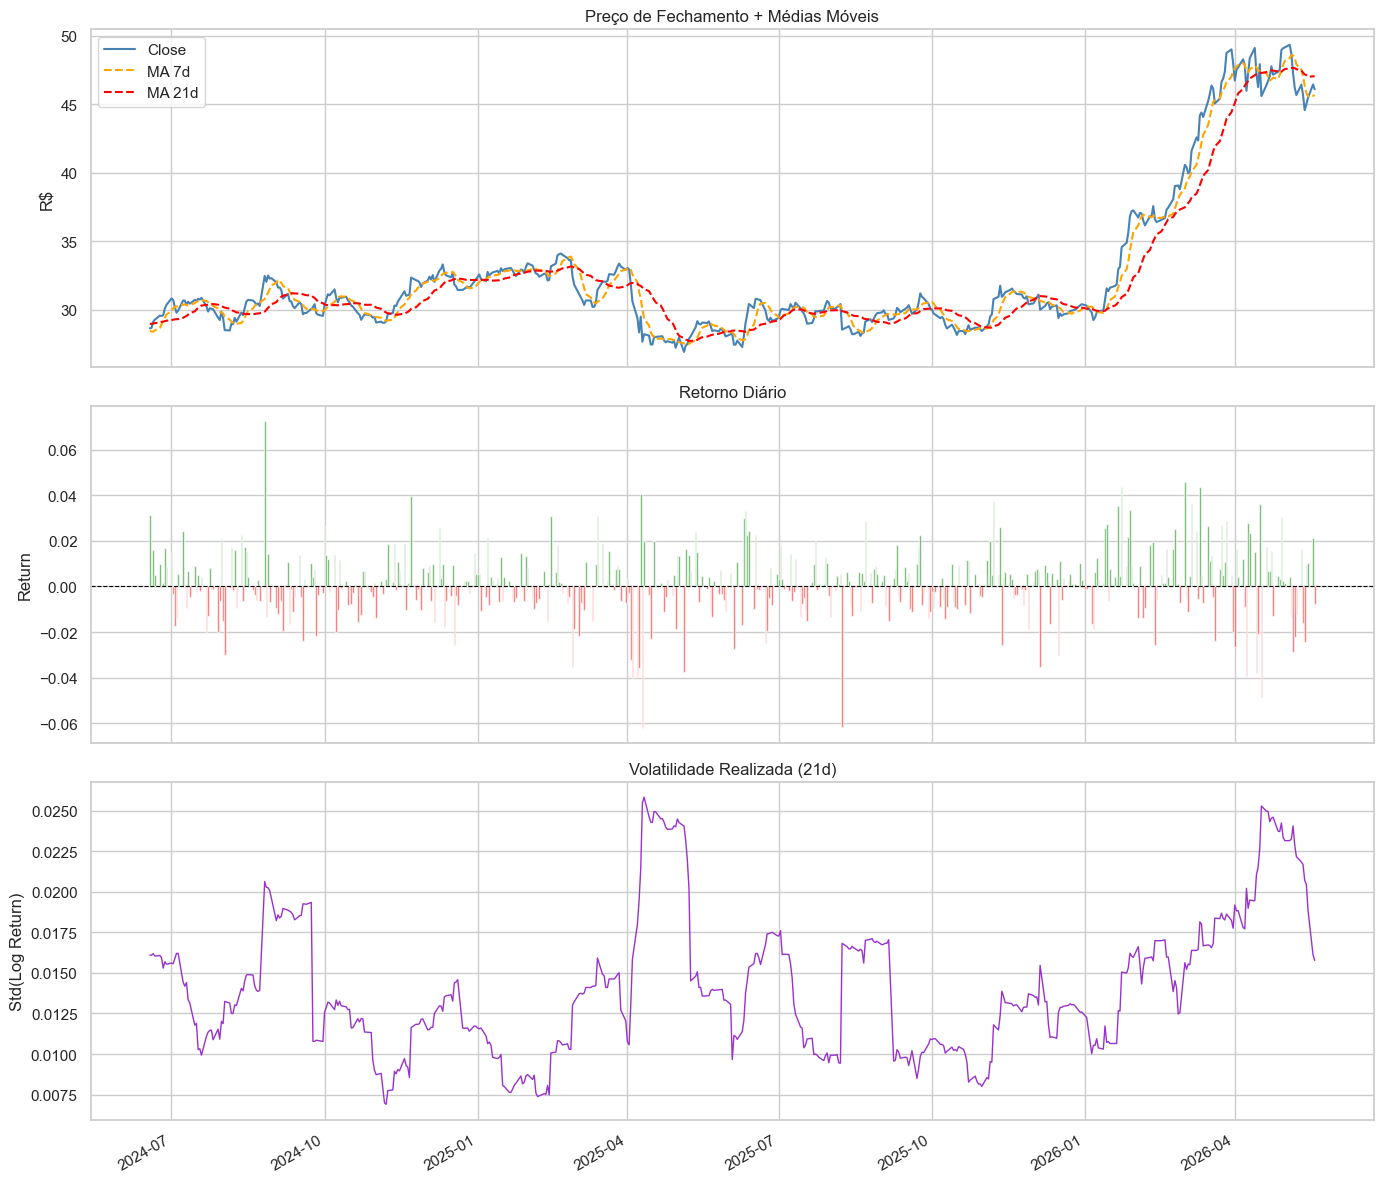

In [71]:
# Painel final: Close + Médias Móveis + Retornos + Volatilidade
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df_feat.index, df_feat["Close"],  label="Close",  color="steelblue")
axes[0].plot(df_feat.index, df_feat["MA_7"],   label="MA 7d",  color="orange",    linestyle="--")
axes[0].plot(df_feat.index, df_feat["MA_21"],  label="MA 21d", color="red",       linestyle="--")
axes[0].set_title("Preço de Fechamento + Médias Móveis")
axes[0].set_ylabel("R$")
axes[0].legend()

bar_colors = ["green" if r >= 0 else "red" for r in df_feat["Return"]]
axes[1].bar(df_feat.index, df_feat["Return"], color=bar_colors, alpha=0.7, width=1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Retorno Diário")
axes[1].set_ylabel("Return")

axes[2].plot(df_feat.index, df_feat["Volatility_21"], color="darkorchid", linewidth=1)
axes[2].set_title("Volatilidade Realizada (21d)")
axes[2].set_ylabel("Std(Log Return)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Preparação para o Modelo LSTM

### Decisões de design
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Feature alvo | `Close` | Objetivo: prever o próximo preço de fechamento |
| Normalização | MinMaxScaler [0, 1] ajustado em todo o dataset | Preços financeiros são não-estacionários: o período de teste tem preços acima do máximo do treino. Escalar só no treino geraria inputs > 1 no LSTM, distorcendo previsões. Leve leakage nos parâmetros de escala é aceito; o modelo treina apenas nas sequências de treino. |
| Janela temporal (`LOOKBACK`) | 120 dias | Captura ~4,5 meses de contexto histórico |
| Split treino/teste | 80/20 | Proporção padrão para séries financeiras |

In [72]:
LOOKBACK   = 120
TEST_RATIO = 0.20

close_vals = df_feat[["Close"]].values
split_raw  = int(len(close_vals) * (1 - TEST_RATIO))

# Scaler ajustado em todo o dataset para evitar inputs > 1 no LSTM.
# O set de treino tem preços até ~R$37; o teste chega a ~R$46.
# Com MinMaxScaler fitado só no treino, o LSTM recebe valores fora do range [0,1]
# que nunca viu durante o treino, distorcendo as previsões.
# Leve leakage apenas nos parâmetros de escala (min/max global) — o modelo
# ainda é treinado exclusivamente nas sequências de treino, sem ver o futuro.
scaler = MinMaxScaler(feature_range=(0, 1))
close_scaled = scaler.fit_transform(close_vals)

def build_sequences(data: np.ndarray, lookback: int):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = build_sequences(close_scaled, LOOKBACK)

split  = int(len(X) * (1 - TEST_RATIO))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train = X_train.reshape(*X_train.shape, 1)
X_test  = X_test.reshape(*X_test.shape,  1)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

X_train : (304, 120, 1)  |  y_train : (304,)
X_test  : (77, 120, 1)   |  y_test  : (77,)


## 8. Importações — PyTorch e MLflow

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import mlflow
import mlflow.pytorch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Dispositivo : cpu


## 9. DataLoaders PyTorch

In [75]:
BATCH_SIZE = 16

# Conversão numpy → tensor float32
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches treino : {len(train_loader)}  |  Batches teste : {len(test_loader)}")

Batches treino : 19  |  Batches teste : 5


## 10. Arquitetura LSTM


In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout, 
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


model = LSTMForecaster().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {total_params:,}")

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parâmetros treináveis: 50,497


## 12. Treinamento com MLflow

O MLflow registra automaticamente:
- **Hiperparâmetros** do modelo e do otimizador
- **Loss** (MSE) por época — treino e validação
- **Artefato** do modelo treinado (`mlflow.pytorch.log_model`)

Para visualizar a UI do MLflow execute no terminal:
```bash
mlflow ui
```
e acesse `http://127.0.0.1:5000`.

In [77]:
# Hiperparâmetros
HPARAMS = {
    "ticker"      : TICKER,
    "lookback"    : LOOKBACK,
    "hidden_size" : 64,
    "num_layers"  : 2,
    "dropout"     : 0.2,
    "epochs"      : 200,
    "batch_size"  : BATCH_SIZE,
    "lr"          : 1e-3,
    "optimizer"   : "Adam",
    "loss_fn"     : "MSE",
}

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS["lr"])

# Scheduler: reduz LR pela metade se val_loss não melhorar em 5 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


# ── Experimento MLflow ─────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": []}

mlflow.set_experiment("PETR4_LSTM")
with mlflow.start_run(run_name="lstm_baseline"):
    mlflow.log_params(HPARAMS)

    for epoch in range(1, HPARAMS["epochs"] + 1):
        train_loss = run_epoch(train_loader, train=True)
        val_loss   = run_epoch(test_loader,  train=False)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        mlflow.log_metrics(
            {"train_loss": train_loss, "val_loss": val_loss},
            step=epoch
        )

        if epoch % 10 == 0 or epoch == 1:
            print(f"Época {epoch:3d}/{HPARAMS['epochs']}  "
                  f"train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

    mlflow.pytorch.log_model(model, name="lstm_model")
    run_id = mlflow.active_run().info.run_id
    print(f"\nRun finalizada — ID: {run_id}")

Época   1/200  train_loss=0.012281  val_loss=0.404969
Época  10/200  train_loss=0.004916  val_loss=0.050969
Época  20/200  train_loss=0.001109  val_loss=0.030071
Época  30/200  train_loss=0.001012  val_loss=0.020686
Época  40/200  train_loss=0.000788  val_loss=0.017068
Época  50/200  train_loss=0.000765  val_loss=0.016749
Época  60/200  train_loss=0.000691  val_loss=0.017043
Época  70/200  train_loss=0.000722  val_loss=0.017471
Época  80/200  train_loss=0.000701  val_loss=0.016890
Época  90/200  train_loss=0.000718  val_loss=0.016765
Época 100/200  train_loss=0.000775  val_loss=0.016753
Época 110/200  train_loss=0.000688  val_loss=0.016744
Época 120/200  train_loss=0.000778  val_loss=0.016740
Época 130/200  train_loss=0.000738  val_loss=0.016738
Época 140/200  train_loss=0.000701  val_loss=0.016736
Época 150/200  train_loss=0.000715  val_loss=0.016734
Época 160/200  train_loss=0.000724  val_loss=0.016734
Época 170/200  train_loss=0.000727  val_loss=0.016732
Época 180/200  train_loss=0.

2026/05/20 20:22:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Época 200/200  train_loss=0.000737  val_loss=0.016727

Run finalizada — ID: ccb1430e6849483cbc23a9d2cfbf132f


In [78]:
import pickle
from pathlib import Path

MODEL_DIR = Path("../modelo")
MODEL_DIR.mkdir(exist_ok=True)

payload = {
    "model_state_dict" : model.state_dict(),
    "hparams"          : HPARAMS,
    "scaler"           : scaler,
    "lookback"         : LOOKBACK,
    "ticker"           : TICKER,
}

pkl_path = MODEL_DIR / "lstm_petr4.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(payload, f)

print(f"Modelo salvo em: {pkl_path}")

Modelo salvo em: ..\modelo\lstm_petr4.pkl


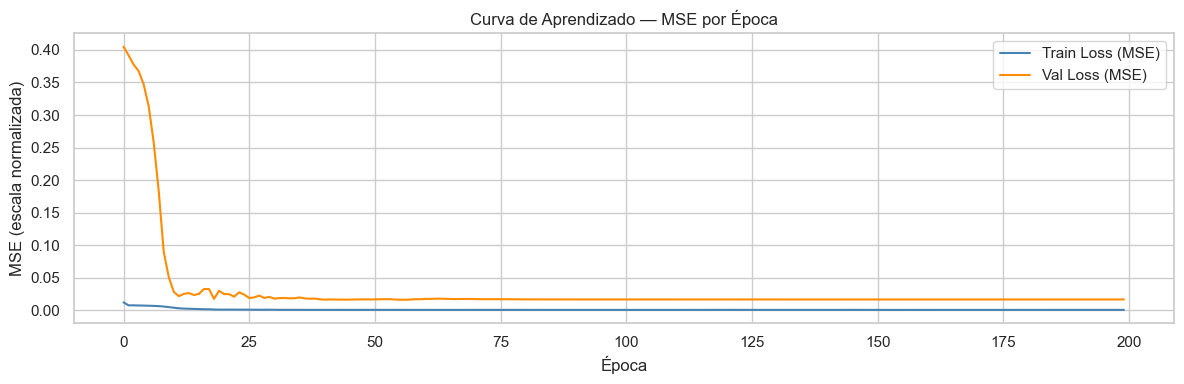

In [79]:
# Curva de aprendizado
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history["train_loss"], label="Train Loss (MSE)", color="steelblue")
ax.plot(history["val_loss"],   label="Val Loss (MSE)",   color="darkorange")
ax.set_title("Curva de Aprendizado — MSE por Época")
ax.set_xlabel("Época")
ax.set_ylabel("MSE (escala normalizada)")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Predições — Escala Original (R$)

In [80]:
model.eval()

def predict(loader):
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)


# Predições normalizadas → escala R$
y_train_pred_n = predict(train_loader)
y_test_pred_n  = predict(test_loader)

y_train_pred = scaler.inverse_transform(y_train_pred_n)
y_test_pred  = scaler.inverse_transform(y_test_pred_n)
y_train_real = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_real  = scaler.inverse_transform(y_test.reshape(-1,  1))

# Datas correspondentes ao set de teste
test_dates = df_feat.index[LOOKBACK + len(X_train):]

print(f"Predições geradas — treino: {len(y_train_pred)}  teste: {len(y_test_pred)}")

Predições geradas — treino: 304  teste: 77


## 14. Métricas de Avaliação — MAE e MAPE

In [81]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    # Evita divisão por zero mascarando valores zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


metrics = {
    "set"  : ["Treino",           "Teste"],
    "MAE"  : [mae(y_train_real,  y_train_pred),  mae(y_test_real,  y_test_pred)],
    "MAPE%": [mape(y_train_real, y_train_pred),  mape(y_test_real, y_test_pred)],
    "RMSE" : [rmse(y_train_real, y_train_pred),  rmse(y_test_real, y_test_pred)],
}
metrics_df = pd.DataFrame(metrics).set_index("set")
print("=== Métricas de Avaliação ===")
print(metrics_df.to_string())

# Registra métricas finais no MLflow (na mesma run)
with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics({
        "test_MAE"  : metrics["MAE"][1],
        "test_MAPE" : metrics["MAPE%"][1],
        "test_RMSE" : metrics["RMSE"][1],
    })

=== Métricas de Avaliação ===
          MAE  MAPE%   RMSE
set                        
Treino 0.4310 1.4122 0.5763
Teste  2.4976 5.5145 2.8991


## 15. Visualização — Preço Real vs. Previsto

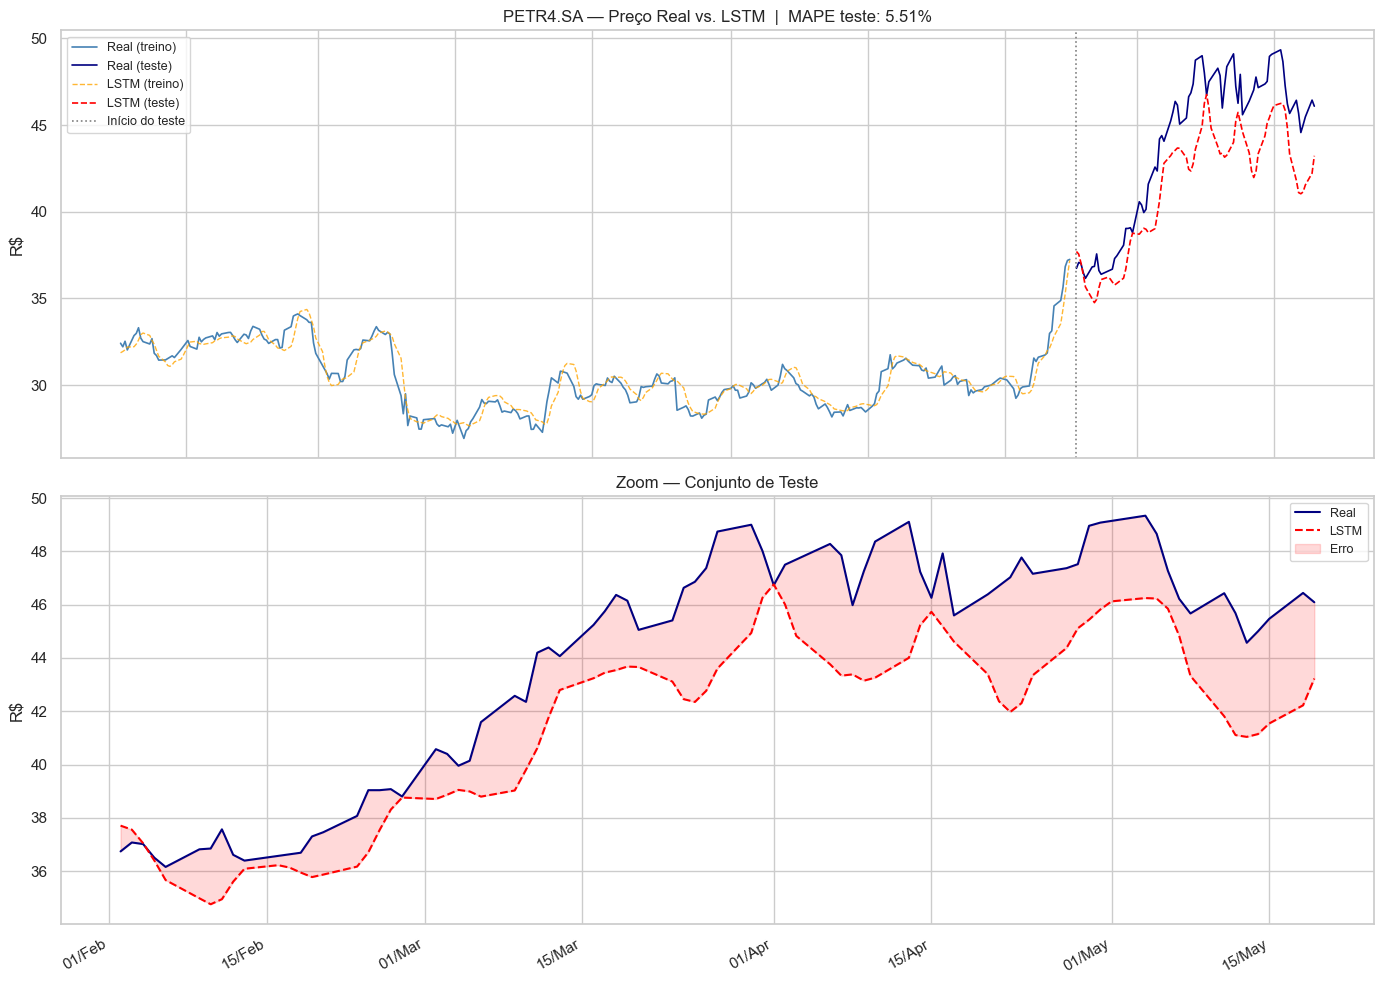

In [82]:
all_dates  = df_feat.index[LOOKBACK:]
train_dates = all_dates[:len(y_train_pred)]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Painel 1: série completa ────────────────────────────────────────────────
axes[0].plot(train_dates, y_train_real, color="steelblue",  label="Real (treino)",  linewidth=1.2)
axes[0].plot(test_dates,  y_test_real,  color="navy",        label="Real (teste)",   linewidth=1.2)
axes[0].plot(train_dates, y_train_pred, color="orange",      label="LSTM (treino)",  linewidth=1,   linestyle="--", alpha=0.8)
axes[0].plot(test_dates,  y_test_pred,  color="red",         label="LSTM (teste)",   linewidth=1.2, linestyle="--")
axes[0].axvline(test_dates[0], color="gray", linestyle=":", linewidth=1.2, label="Início do teste")
axes[0].set_title(f"{TICKER} — Preço Real vs. LSTM  |  MAPE teste: {metrics['MAPE%'][1]:.2f}%")
axes[0].set_ylabel("R$")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))

# ── Painel 2: zoom no período de teste ─────────────────────────────────────
axes[1].plot(test_dates, y_test_real, color="navy",  label="Real",   linewidth=1.5)
axes[1].plot(test_dates, y_test_pred, color="red",   label="LSTM",   linewidth=1.5, linestyle="--")
axes[1].fill_between(test_dates,
                     y_test_real.flatten(),
                     y_test_pred.flatten(),
                     alpha=0.15, color="red", label="Erro")
axes[1].set_title("Zoom — Conjunto de Teste")
axes[1].set_ylabel("R$")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 16. Previsão do Próximo Pregão

In [84]:
model.eval()

# Últimos LOOKBACK dias do dataset completo como janela de entrada
last_window = close_scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
last_window_t = torch.tensor(last_window, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    next_scaled = model(last_window_t).cpu().numpy()

next_price = scaler.inverse_transform(next_scaled)[0, 0]
last_close  = df_feat["Close"].iloc[-1]
variation   = (next_price - last_close) / last_close * 100

print(f"Último Close : R$ {last_close:.2f}  ({df_feat.index[-1].date()})")
print(f"Previsão LSTM : R$ {next_price:.2f}")
print(f"Variação : {variation:+.4f}%")

Último Close : R$ 46.09  (2026-05-19)
Previsão LSTM : R$ 44.00
Variação : -4.5273%
